# 3. Univariate Analysis

## Table of Contents

Recall that: 
* Numerical Risk Factors:
    - age
    - bmi
    - bloodpressure
    - children
* Categorical Risk Factors:
    - gender
    - diabetic
    - smoker
    - region
* Target variable:
    - claim

# Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils import display_side_by_side


print("loaded")

loaded


In [6]:
df = pd.read_csv("/Users/yushinnam/projects/health-insurance-claims/data/processed/insurance_data_cleaned.csv")

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['index', 'PatientID'])
categorical_cols = df.select_dtypes(include='object').columns


df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24,male,30.1,87,No,0,No,southeast,1131.51
2,7,8,19,male,41.1,100,No,0,No,northwest,1146.80
3,8,9,20,male,43.0,86,No,0,No,northwest,1149.40
4,9,10,30,male,53.1,97,No,0,No,northwest,1163.46


## Target Variable

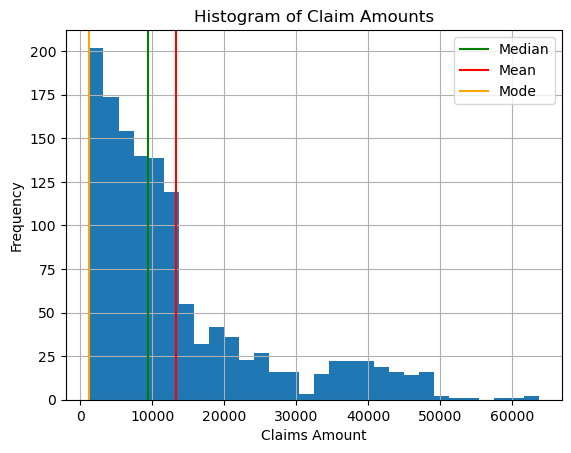

In [7]:
# Central Tendencies
claim_mean = df['claim'].mean()
claim_median = df['claim'].median()
claim_mode = df['claim'].mode()[0]
claim_var = df['claim'].var()

df['claim'].hist(bins=30)
plt.axvline(claim_median, color='green', label='Median')
plt.axvline(claim_mean, color='red', label = 'Mean')
plt.axvline(claim_mode, color='orange', label = 'Mode')
plt.xlabel("Claims Amount")
plt.ylabel("Frequency")
plt.title("Histogram of Claim Amounts")
plt.legend()
plt.show()

In [8]:
print('Mean^2: ', claim_mean**2,"Variance: ", claim_var)

Mean^2:  177562192.32499027 Variance:  146642913.79497418


The claim distribution exhibits strong positive skewness. The mean substantially exceeds the median, indicating sensitivity to high-cost claims. The majority of observations are present below $15,000, while a small subset extends beyond $50,000. Additionally, the mean and the variance of claims amount is given above. This heavy-tailed behaviour is characteristic of insurance severity data. It is necessary to check the appropriateness of a Gamma (or Lognormal) distribution with log link function.

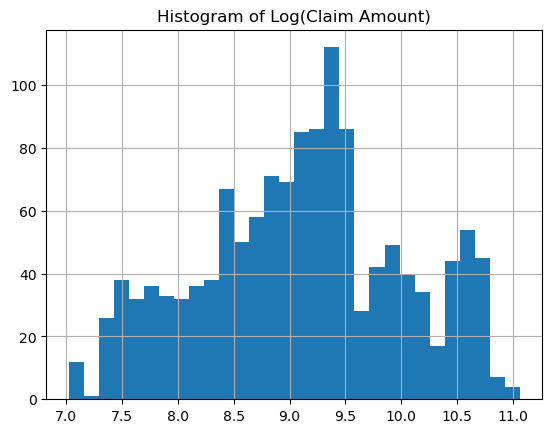

In [9]:
np.log(df['claim']).hist(bins=30)
plt.title("Histogram of Log(Claim Amount)")
plt.show()

The reduction in skewness under log transformation suggests that it supports the use of a positive-support GLM with log link, such as Gamma.

**Summary**:
* Mean $\approx$ 13,325
* Median $\approx$ 9,413
* Std $\approx$ 12,110
* Range: 1,121 - 63,770
* 75th percentile $\approx$ 16,781

**Interpretation**
* Mean > median $\Rightarrow$ right skew
* Std nearly as large as mean $\Rightarrow$ high dispersion
* Large gap between 75th percentile and max $\Rightarrow$ heavy tail

Given the coefficient of variation: $$\frac{\text{std}}{\text{mean}} = \frac{12110}{13325} \approx 0.91$$ The claim distribution exhibits strong positive skewness with mean exceeding median and substantial dispersion. The larger upper tail suggests multiplicative variability, supporting a Gamma GLM with log link function as a plausible modeling framework. 

# Numerical Risk Factors

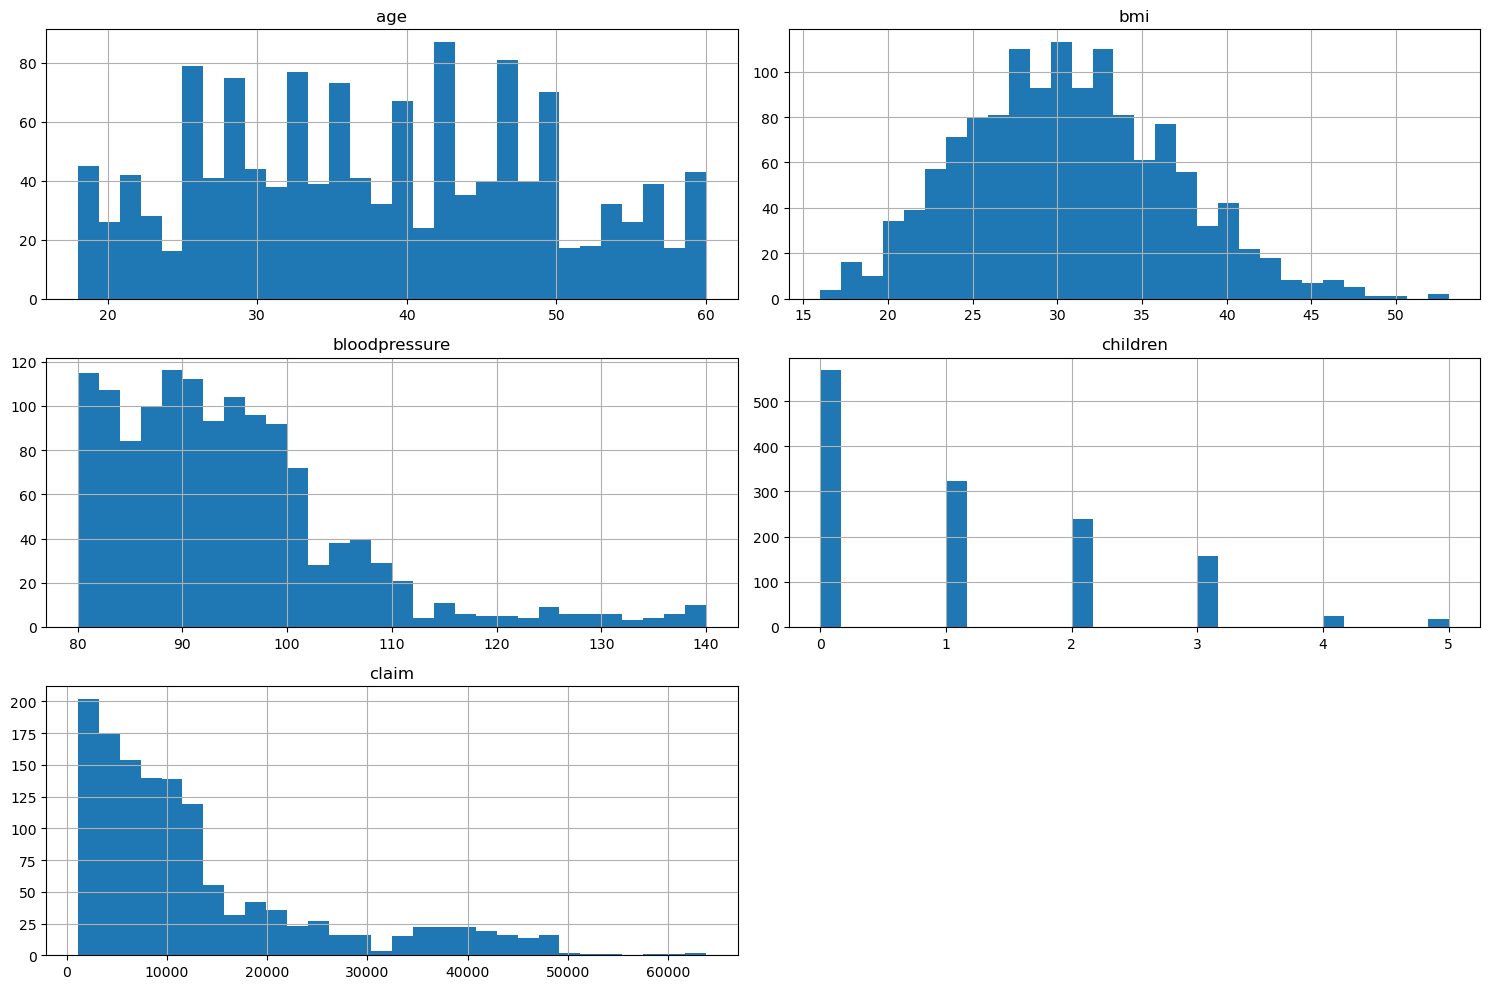

In [10]:
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

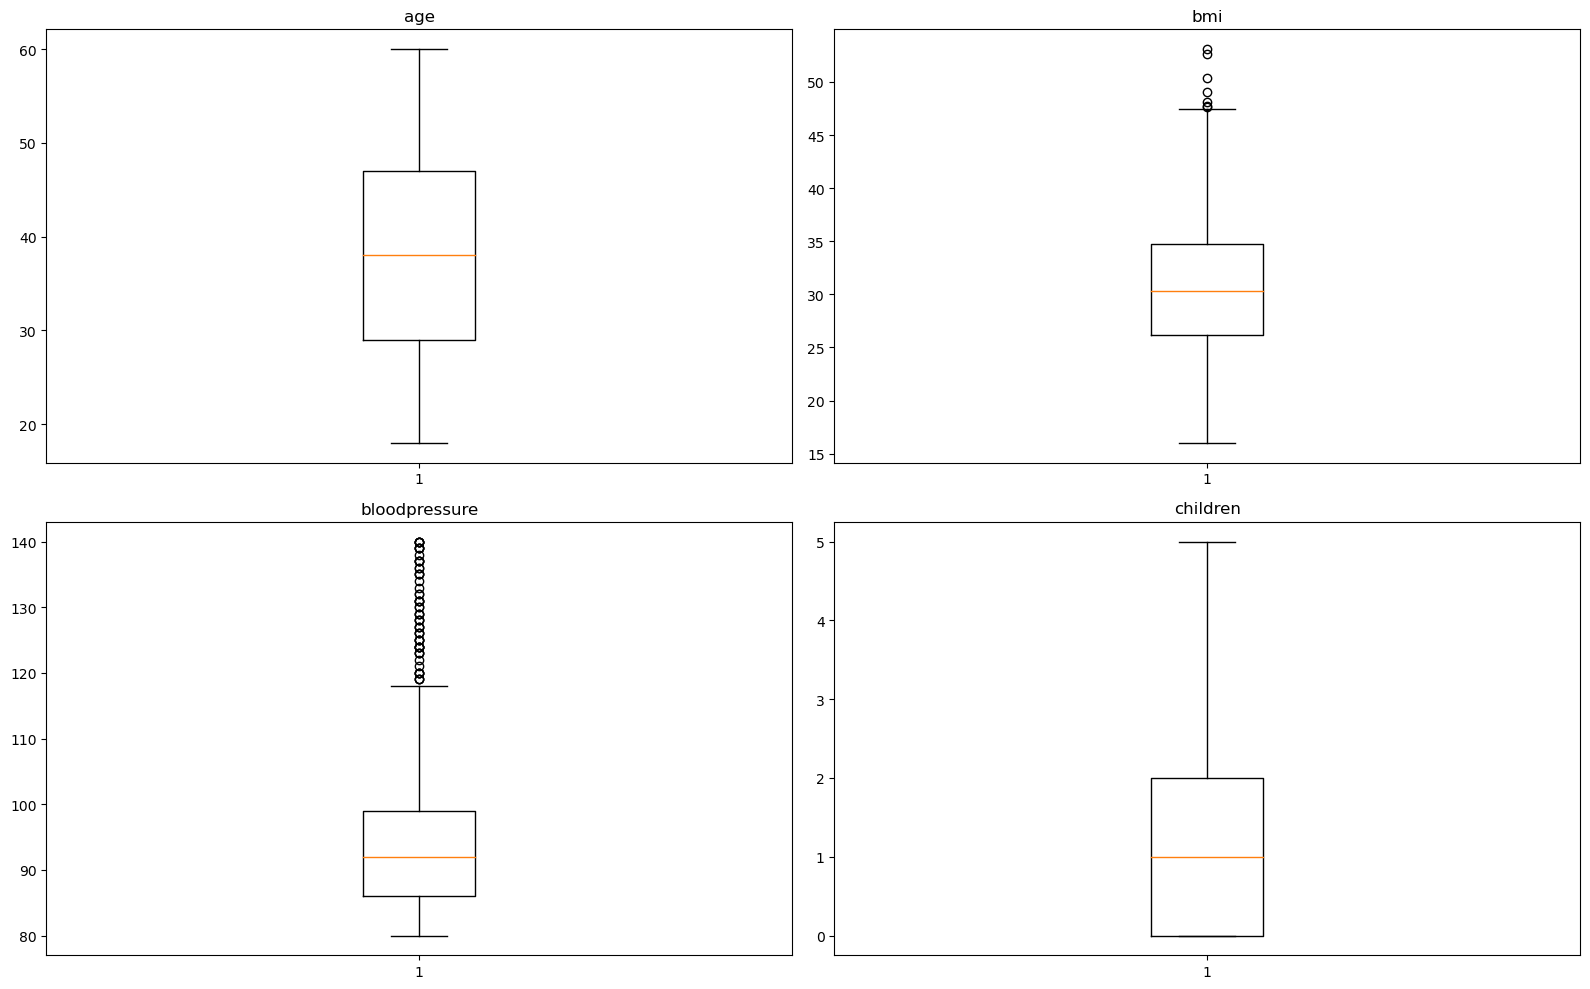

In [11]:
numerical_cols_small = numerical_cols.copy().drop("claim")

fig, axes = plt.subplots(2,2, figsize=(16,10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols_small):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [12]:
df[numerical_cols].describe()

,age,bmi,bloodpressure,children,claim
count,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000
mean,38.086336,30.658333,94.189189,1.099850,13325.246426
std,11.112804,6.118967,11.445173,1.205958,12109.620712
min,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,29.000000,26.200000,86.000000,0.000000,4760.157500
50%,38.000000,30.350000,92.000000,1.000000,9412.965000
75%,47.000000,34.725000,99.000000,2.000000,16781.327500
max,60.000000,53.100000,140.000000,5.000000,63770.430000


## Age

**Summary**:
* Mean $\approx$ 38
* Std $\approx$ 11.1
* Range: 18 - 60

**Interpretation**:
* Fairly good spread across adult population
* No unrealistic values
* median $\approx$ mean $\Rightarrow$ roughly symmetric
* No extreme outliers


## BMI

**Summary**:
* Mean $\approx$ 30.7
* Std $\approx$ 6.1
* Range: 16 - 53

**Interpretation**:
* Mean around 30 $\Rightarrow$ this dataset consists of obese individuals, which can cause selection bias
* Distribution looks roughly bell-shaped (normally distributed)
* Right tail slightly extended
* High BMI is usually associated with chronic disease and thus higher medical utilization $\Rightarrow$ This might be a strong candidate predictor for severity

## Blood Pressure

**Summary**:
* Mean $\approx$ 94
* Std $\approx$ 11.4
* Range: 80 - 94
* Slight right skew

**Interpretation**:
* Distribution declines toward higher values
    * May need to take a look at relationship between BMI and blood pressure
* One thing to note is that the data might have been truncated because the lower bound is very cleanly cut
* Although it seems to have many outliers, as shown in the boxplot, we will keep these because these may carry important information for claim severity.

## Children
**Summary**:
* Mean $\approx$ 1.1
* Std $\approx$ 1.2
* Median $\approx$ 1.0
* Range: 0-5

**Interpretation**
* Many individuals have no children
* Distribution is highly discrete
* Since range is small, categorical modeling might be better for this factor

# Categorical Risk Factors

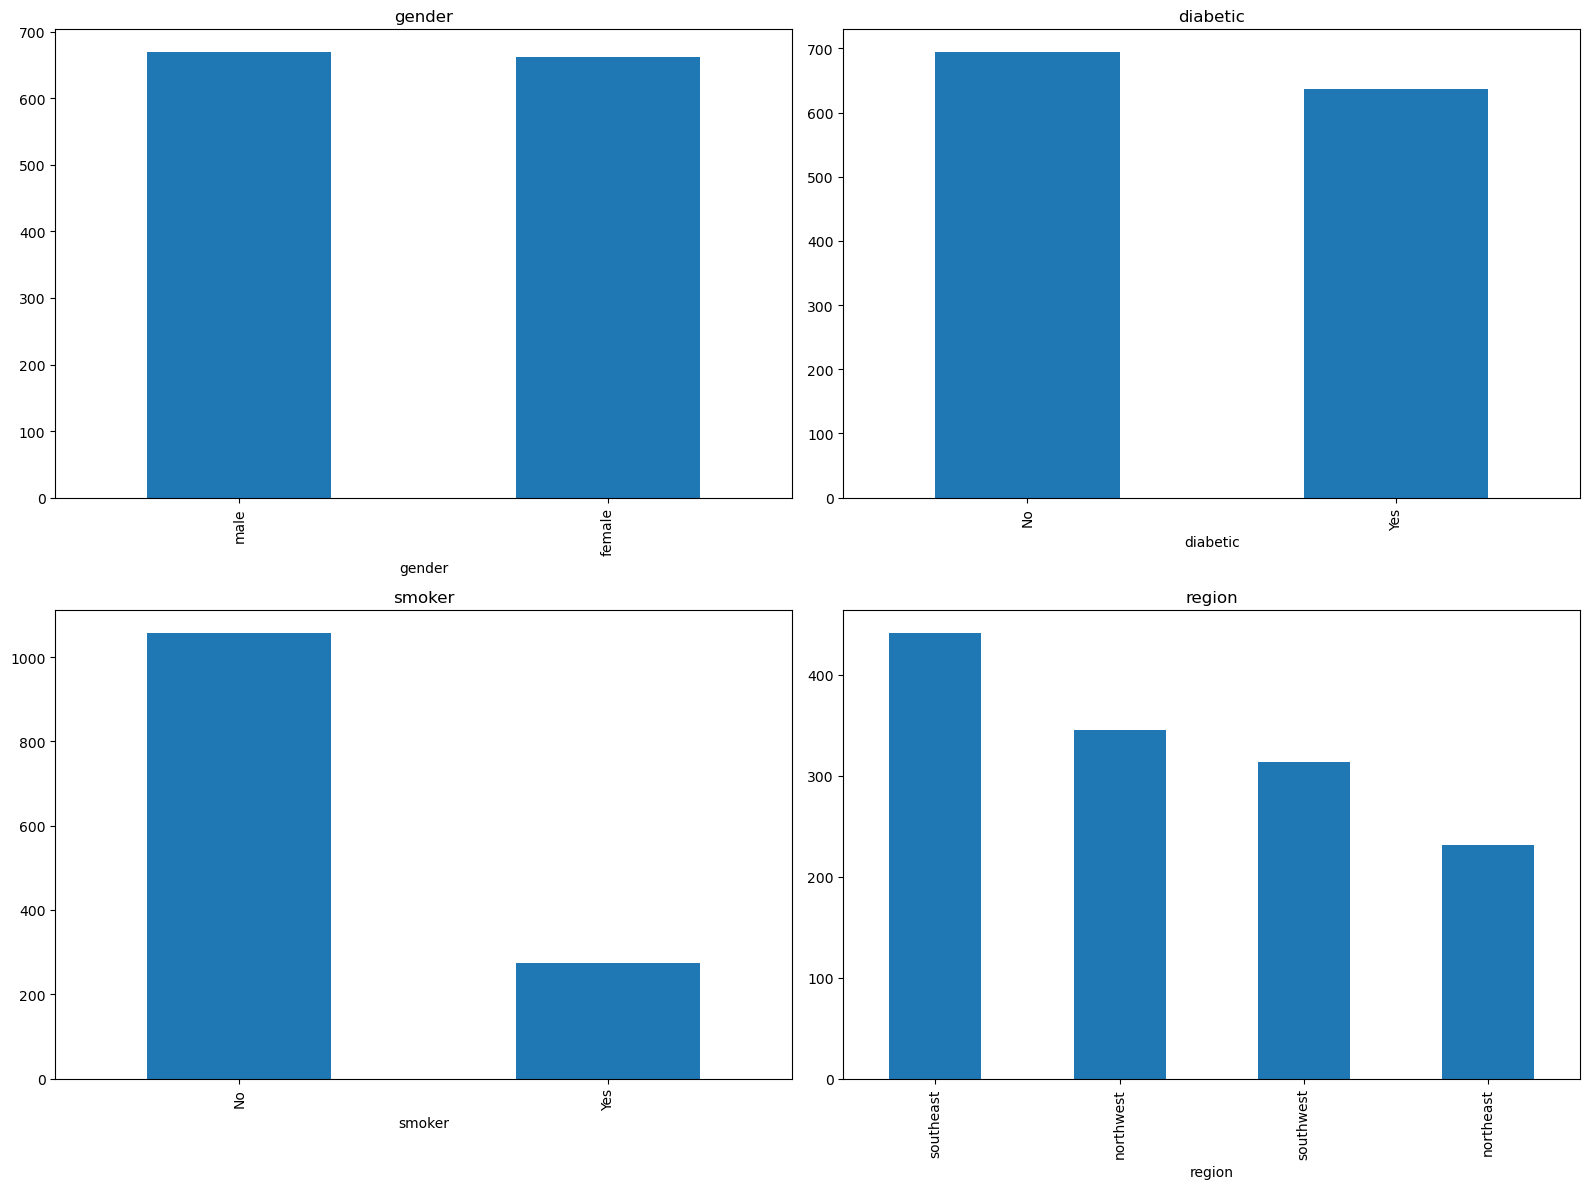

In [13]:
fig, axes = plt.subplots(2,2, figsize=(16,12))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Gender

**Interpretation**:
* No class imbalance
* Good representation for male and female

## Diabetic
**Interpretation**:
* Slight imbalance, but reasonable
* Not too rare $\Rightarrow$ still reliable for modeling

**Modeling Implication**:
* This is a clinical risk indicator
    * Thus, strong candidate for severity modeling

## Smoker
**Interpretation**:
* Strong imbalance $\Rightarrow$ majority non-smokers
* Small smoker group, but not too small
* Likely the most important variable

**Modeling Implication**:
* High explanatory power expected
* Watch for strong coefficient in GLM

## Region

**Interpretation**:
* Moderate imbalance
* Still usable

**Actuarial Insight**:
* Captures geographic variation:
    * healthcare cost differences
    * lifestyle differences

The categorical variables exhibi generally well-balanced distributions across gender and region, while the smoker and diabetic indicators are moderately imbalanced. In particular, the smoker variable shows a smaller high-risk subgoup, which is expected to have a strong impact on claim severity. overall, the distributions are suitable for modeling without requiring category aggregation.